# LAB | Different Ways to Chunk Podcast and PDF

## CODE - Do not touch!!

### Setup and Data Loading

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import scipy.io.wavfile as wavfile
import cohere
from openai import OpenAI
import io
import os
from dotenv import load_dotenv
from pydub import AudioSegment
from pathlib import Path
from PyPDF2 import PdfReader
import tiktoken
from langchain_text_splitters import RecursiveCharacterTextSplitter, TokenTextSplitter

load_dotenv()

True

### Helper functions

In [ ]:
def transcribe_openai(audio_path: str, client: OpenAI) -> str:
    """
    Transcribe an audio file using OpenAI Whisper.

    Args:
        audio_path (str): Path to the audio file
        client (OpenAI): Initialized OpenAI client

    Returns:
        str: Transcribed text
    """
    with open(audio_path, "rb") as audio_file:
        print("🤖 Transcribing with Whisper...")
        transcription = client.audio.transcriptions.create(
            model="whisper-1",
            file=audio_file
        )

        print("\n📝 Transcription:")
        print(transcription.text)

    return transcription.text

In [ ]:
def extract_pdf(pdf_path: str) -> str:
    """Extract text from a PDF file.

    Args:
        pdf_path (str): Path to the PDF file.

    Returns:
        str: Extracted text from the PDF.
    """
    
    pdf_path = Path(pdf_path)
    if not pdf_path.exists():
        raise FileNotFoundError(f"PDF file not found: {pdf_path}")

    text_parts = []
    with open(pdf_path, "rb") as pdf_file:
        reader = PdfReader(pdf_file)
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text_parts.append(page_text)

    return "\n".join(text_parts)

In [ ]:
# Custom chunking function (replaces RecursiveCharacterTextSplitter)
def chunk_text_fixed_size(text, chunk_size=500, chunk_overlap=50):
    """
    Split text into chunks with overlap.
    
    Args:
        text: The text to chunk
        chunk_size: Maximum size of each chunk
        chunk_overlap: Number of characters to overlap between chunks
    
    Returns:
        List of chunk dictionaries with 'page_content' and 'metadata'
    """
    chunks = []
    start = 0
    
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]
        
        chunks.append({
            "page_content": chunk,
            "metadata": {"start": start, "end": end}
        })
        
        # Move start position forward, accounting for overlap
        start += chunk_size - chunk_overlap
        
        # Prevent infinite loop if chunk_size <= chunk_overlap
        if chunk_size <= chunk_overlap:
            break
    
    return chunks

In [ ]:
def print_chunks(chunks, start, end, encoding):
    """
    Print a summary and content of a range of chunks from a list of chunks.
    
    Args:
        chunks: List of chunks to print (can be strings or dictionaries with 'page_content')
        start: Starting index (inclusive)
        end: Ending index (exclusive)
        encoding: Tiktoken encoding for token counting
    """
    # Print summary with token and character counts
    print("====== SUMMARY ======\n")
    for chunk_idx in range(start, end):
        if chunk_idx < len(chunks):
            if isinstance(chunks[chunk_idx], dict) and "page_content" in chunks[chunk_idx]:
                chunk_content = chunks[chunk_idx]["page_content"]
            else:
                chunk_content = chunks[chunk_idx]
            
            token_count = len(encoding.encode(chunk_content))
            char_count = len(chunk_content)
            print(f"Chunk {chunk_idx}: {token_count} tokens, {char_count} characters")
    
    print("\n====== CHUNKS ======\n")
    # Print chunk contents
    for chunk_idx in range(start, end):
        if chunk_idx < len(chunks):
            if isinstance(chunks[chunk_idx], dict) and "page_content" in chunks[chunk_idx]:
                chunk_content = chunks[chunk_idx]["page_content"]
            else:
                chunk_content = chunks[chunk_idx]
            
            print(f"====== Chunk {chunk_idx} ======\n")
            print(chunk_content)
            print()


In [44]:
def plot_chunk_statistics(chunks, encoding):
    """Plot chunk length and token count histograms side by side.

    Args:
        chunks: List of chunks to analyze. Chunks may be strings or dicts with 'page_content'.
        encoding: Tiktoken encoding for token counting.
    """
    chunk_texts = [chunk["page_content"] if isinstance(chunk, dict) and "page_content" in chunk else chunk for chunk in chunks]
    char_lengths = [len(text) for text in chunk_texts]
    token_counts = [len(encoding.encode(text)) for text in chunk_texts]

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

    axes[0].hist(char_lengths, bins=20, color="#4C72B0", edgecolor="black")
    axes[0].set_title("Chunk Character Length Distribution")
    axes[0].set_xlabel("Characters per Chunk")
    axes[0].set_ylabel("Number of Chunks")

    axes[1].hist(token_counts, bins=20, color="#55A868", edgecolor="black")
    axes[1].set_title("Chunk Token Count Distribution")
    axes[1].set_xlabel("Tokens per Chunk")
    axes[1].set_ylabel("Number of Chunks")

    fig.suptitle("Chunk Size and Token Count Histograms", fontsize=16)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## EXECUTION

### Step 1: Inputs

In [27]:
oai_client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
cohere_client = cohere.Client(api_key=os.getenv("COHERE_API_KEY"))

audio_sample = "data/The_Blueprint_For_Trustworthy_AI.m4a"
pdf_file = "data/ai_hleg_ethics_guidelines_for_trustworthy_ai-en_87F84A41-A6E8-F38C-BFF661481B40077B_60419.pdf"

encoding = tiktoken.get_encoding("cl100k_base")

In [ ]:
# transcription = transcribe_openai(audio_sample, oai_client)
# print(transcription)

In [28]:
extracted_text = extract_pdf(pdf_file)
# print(extracted_text)

### Step 2: Fixed-Size Chunking

In [ ]:
fs_chunk_sizes = [500, 1000, 2000] # chunk sizes for fixed-size chunking
fs_chunk_ovlap = [0, 50, 100] # overlap for fixed-size chunking

fixed_size = []

for s in fs_chunk_sizes:
    size_s = []
    for o in fs_chunk_ovlap:
        print(f"============ Chunk size: {s}, Overlap: {o} ============")
        chunks = chunk_text_fixed_size(extracted_text, chunk_size=s, chunk_overlap=o)
        print(f"Number of chunks: {len(chunks)}\n")
        size_s.append(chunks)
    fixed_size.append(size_s)

In [ ]:
print(f"====== EXAMPLES FIXED SIZE CHUNKING ======\n")

print(f"====== Chunk size = 500, Overlap = 0 ======\n")
chunk1 = fixed_size[0][0][0] # chunk size 500, overlap 0, first chunk
print(chunk1)
chunk2 = fixed_size[0][0][1] # chunk size 500, overlap 0, second chunk
print(chunk2)
chunk3 = fixed_size[0][0][2] # chunk size 500, overlap 0, third chunk
print(chunk3)

print(f"====== Chunk size = 500, Overlap = 50 ======\n")
chunk1 = fixed_size[0][1][0] # chunk size 500, overlap 50, first chunk
print(chunk1)
chunk2 = fixed_size[0][1][1] # chunk size 500, overlap 50, second chunk
print(chunk2)
chunk3 = fixed_size[0][1][2] # chunk size 500, overlap 50, third chunk
print(chunk3)

### Step 3: Recursive Character Chunking

In [ ]:
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]
)
 
pdf_chunks_recursive = recursive_splitter.split_text(extracted_text)
print(f"Number of chunks: {len(pdf_chunks_recursive)}\n")

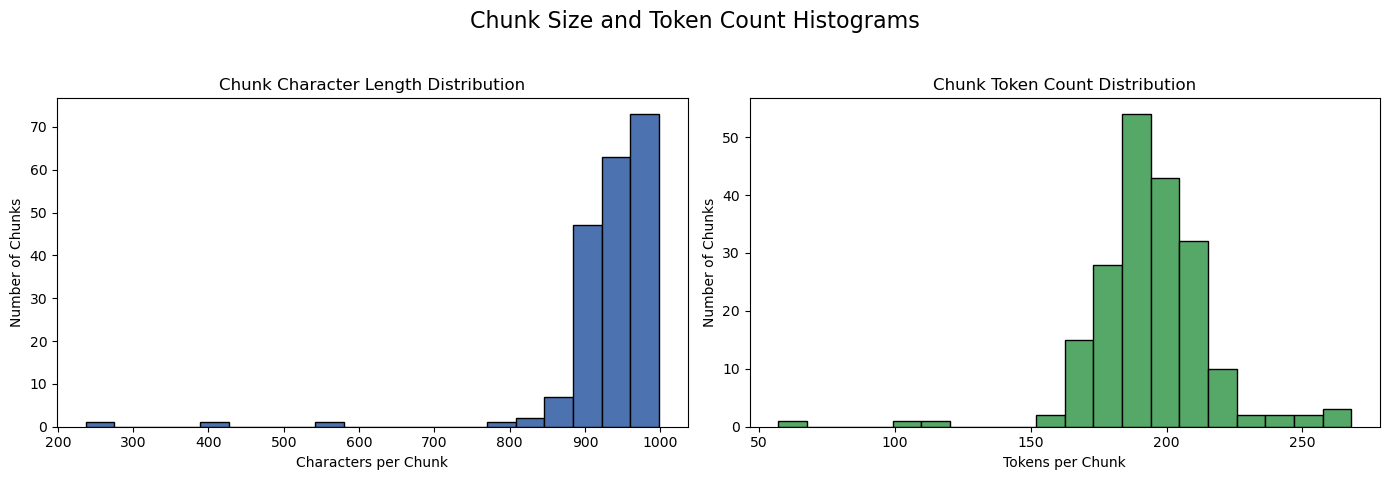

====== EXAMPLES RECURSIVE CHUNKING ======

====== SUMMARY ======

Chunk 2: 222 tokens, 983 characters
Chunk 3: 258 tokens, 942 characters
Chunk 4: 214 tokens, 997 characters
Chunk 5: 199 tokens, 966 characters
Chunk 6: 201 tokens, 965 characters

====== CHUNKS ======

====== Chunk 2 ======

might be made of the following information. The contents of this working document  are the sole responsibility of the High -
Level Expert Group on Artificial Intelligence (AI HLEG). Although Commission staff  facilitated  the preparation of the 
Guidelines, the views expressed in this document  reflect the opinion of the AI HLEG  and may not in any circumstances be 
regarded as reflecting  an official position of the European Commission.  
 
More information on the High -Level Exp ert Group on Artificial Intelligence is available online  (https://ec.europa.eu/digital -
single -market/en/high -level -expert -group -artificial -intelligence ).  
The reuse policy of European Commission documents is reg

In [47]:
plot_chunk_statistics(pdf_chunks_recursive, encoding)
print(f"====== EXAMPLES RECURSIVE CHUNKING ======\n")
print_chunks(pdf_chunks_recursive, 2, 7, encoding)

### Step 4: Token-Based Chunking

In [ ]:
# Token-based chunking
token_splitter = TokenTextSplitter(
    chunk_size=250,
    chunk_overlap=50
)
 
pdf_chunks_tokens = token_splitter.split_text(extracted_text)
print(f"Number of chunks: {len(pdf_chunks_tokens)}\n")

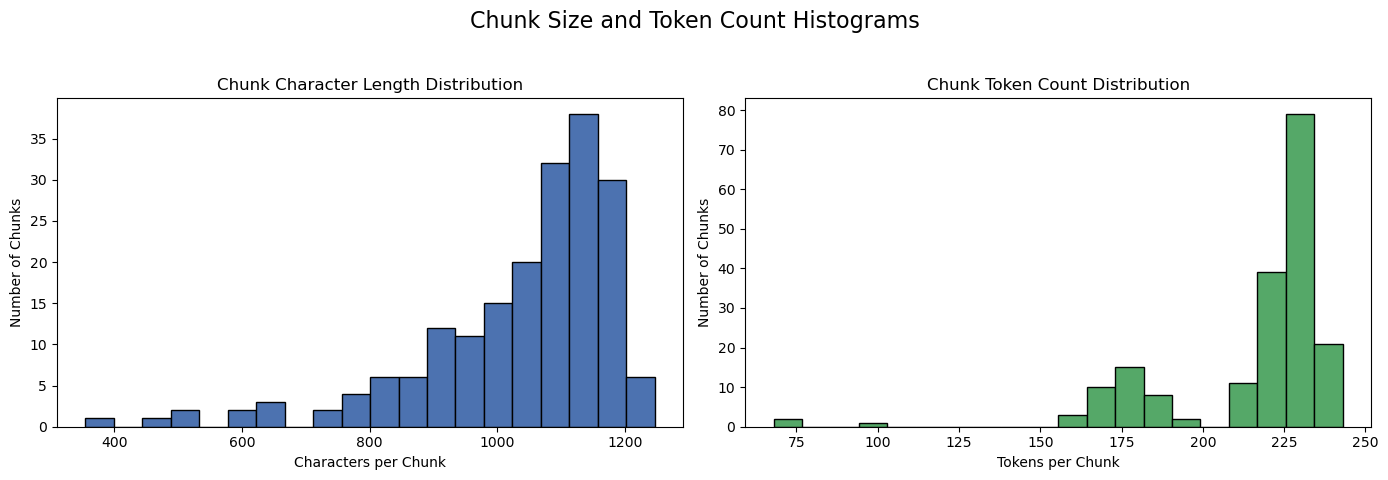

====== EXAMPLES TOKEN-BASED CHUNKING ======

====== SUMMARY ======

Chunk 2: 231 tokens, 1140 characters
Chunk 3: 193 tokens, 719 characters
Chunk 4: 196 tokens, 777 characters
Chunk 5: 237 tokens, 1125 characters
Chunk 6: 232 tokens, 1140 characters

====== CHUNKS ======

====== Chunk 2 ======

 subject to an open consultation which 
generated feedback from more than 500 contributors. We wish to explicitly and warmly tha nk all those who contributed 
their feedback on the document's first draft, which was considered in the preparation of this revised version.  
 
Neither the European Commission nor any person acting on behalf of the Commission is responsible for the use which 
might be made of the following information. The contents of this working document  are the sole responsibility of the High -
Level Expert Group on Artificial Intelligence (AI HLEG). Although Commission staff  facilitated  the preparation of the 
Guidelines, the views expressed in this document  reflect the opini

In [49]:
plot_chunk_statistics(pdf_chunks_tokens, encoding)
print(f"====== EXAMPLES TOKEN-BASED CHUNKING ======\n")
print_chunks(pdf_chunks_tokens, 2, 7, encoding)

## DISCUSSION

### Steps 6, 7, 8: Visualize and Compare Results, Analyze Chunk Quality, Recommendation

**Recursive chunking:** chunk-size 1000 characters

**Token-based chunking:** chunk-size 250 tokens

| Chunk | Recursive | Token-Based |
|----------|------|------|
| 2 | Tokens: 222, Characters: 983 | Tokens: 231, Characters: 1140 |
| 3 | Tokens: 258, Characters: 942 | Tokens: 193, Characters: 719 |
| 4 | Tokens: 214, Characters: 997 | Tokens: 196, Characters: 777 |
| 5 | Tokens: 199, Characters: 966 | Tokens: 237, Characters: 1125 |
| 6 | Tokens: 201, Characters: 965 | Tokens: 232, Characters: 1140 |

Fixed-size chunking breaks not only sentences, but also words in the middle. It does not differentiate paragraph boundaries from sentence endings or new lines in the original PDF.

Recursive chunking is an improvement. It does not cut words anymore, and it tries not to cut sentences. However, it does set chunk boundaries at signs like commas or hyphens, thus breaking complex sentences into different chunks.

It does not respect the section headers in the PDF, or at least not perfectly. For example, chunk number 2 contains the title "Table of contents" and its first entry. It would be better if it would have been ended prior to that.

With token-based chunking, the separation is worse than with recursive chunking. Token-based chunking also does not cut words, but it does break sentences into different chunks.

For those, reasons, the **recommended strategy** is **recursive chunking**.

| Strategy | Pros | Cons | Best For |
|----------|------|------|----------|
| Fixed-Size | Simple, predictable | Breaks context | Uniform content |
| Recursive | Preserves structure | More complex | Structured docs |
| Token-Based | Accurate for LLMs | Requires tokenizer | LLM integration |
| Semantic | Meaning-based | Computationally expensive | Complex content |